# Assignment 1.1, 1.2 and 1.3 - Gamma Correction

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.color import rgb2hsv, hsv2rgb

In [3]:
def gamma_transform_gray(gray_image, gamma):
    """Apply gamma transform to a grayscale image in range [0, 255]."""
    if gamma <= 0:
        raise ValueError("gamma must be > 0")

    img = gray_image.astype(np.float32) / 255.0
    transformed = np.power(img, gamma)
    return (transformed * 255.0).clip(0, 255).astype(np.uint8)

## 1.1 Gamma transform on grayscale image (`KU_Logo.png`)

In [4]:
gray_path = 'KU_Logo.png'
gray = Image.open(gray_path).convert('L')
gray_np = np.array(gray)

gamma_values = [0.4, 0.8, 1.0, 1.6, 2.2]
gray_results = [gamma_transform_gray(gray_np, g) for g in gamma_values]

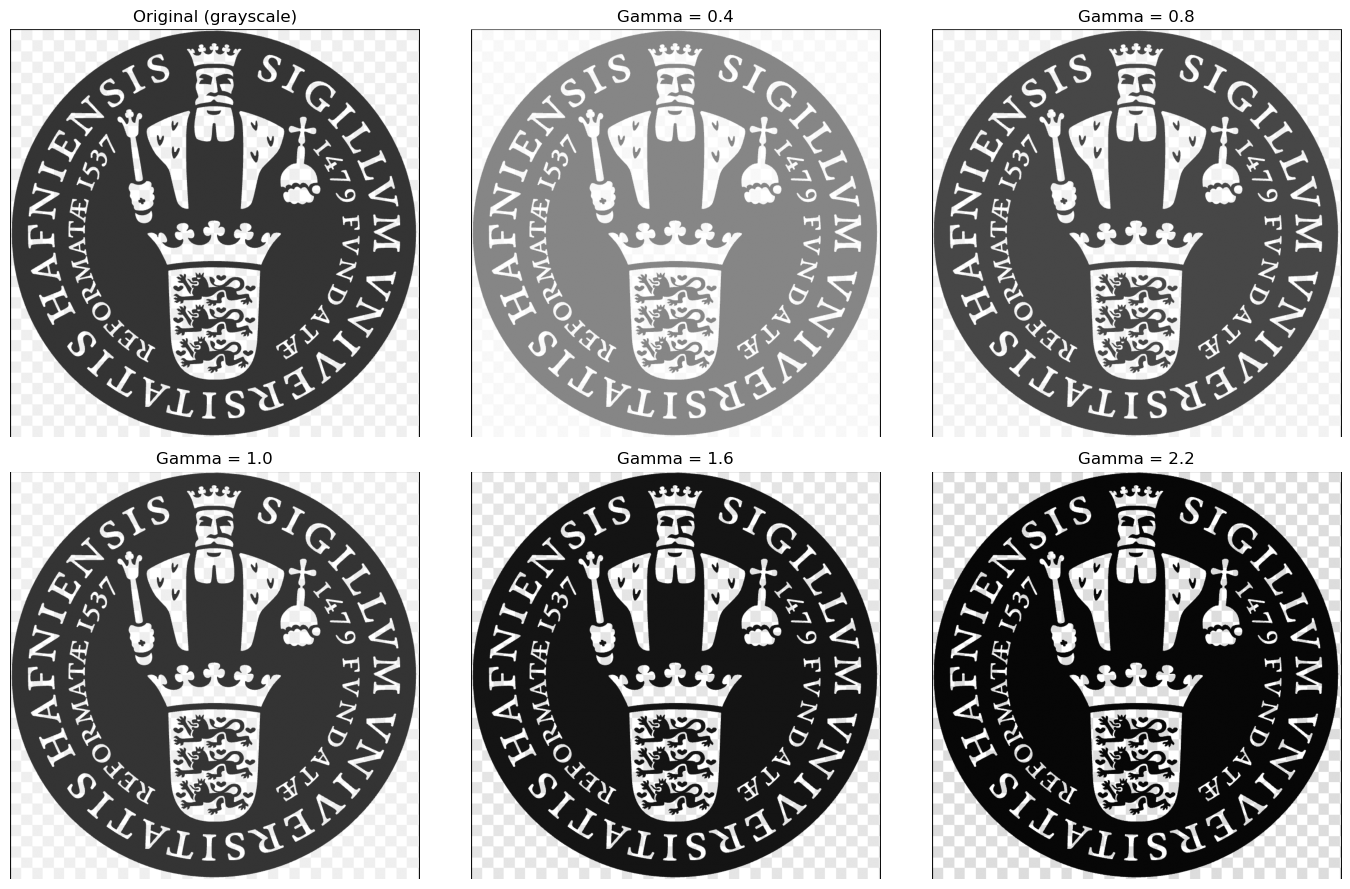

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

axes[0].imshow(gray_np, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original (grayscale)')
axes[0].axis('off')

for i, (g, img) in enumerate(zip(gamma_values, gray_results), start=1):
    axes[i].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[i].set_title(f'Gamma = {g}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 1.2 Same gamma function to each RGB channel (`autumn.tif`)

In [ ]:
autumn_path = 'autumn.tif'
autumn_rgb = np.array(Image.open(autumn_path).convert('RGB'))

gamma_rgb = 0.8 

r_corr = gamma_transform_gray(autumn_rgb[:, :, 0], gamma_rgb)
g_corr = gamma_transform_gray(autumn_rgb[:, :, 1], gamma_rgb)
b_corr = gamma_transform_gray(autumn_rgb[:, :, 2], gamma_rgb)

autumn_rgb_gamma = np.stack([r_corr, g_corr, b_corr], axis=-1)

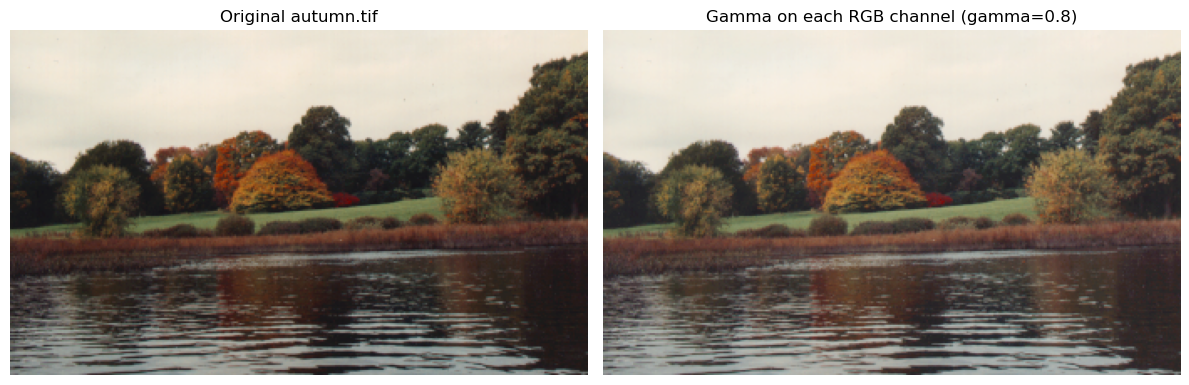

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(autumn_rgb)
plt.title('Original autumn.tif')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(autumn_rgb_gamma)
plt.title(f'Gamma on each RGB channel (gamma={gamma_rgb})')
plt.axis('off')

plt.tight_layout()
plt.show()

## 1.3 Gamma in HSV space (on V-channel only)

In [8]:
gamma_hsv = gamma_rgb  # Same gamma to make a fair comparison

autumn_rgb_float = autumn_rgb.astype(np.float32) / 255.0
autumn_hsv = rgb2hsv(autumn_rgb_float)

# Same grayscale gamma function to the V channel
v_channel_uint8 = (autumn_hsv[:, :, 2] * 255.0).clip(0, 255).astype(np.uint8)
v_channel_gamma_uint8 = gamma_transform_gray(v_channel_uint8, gamma_hsv)
autumn_hsv[:, :, 2] = v_channel_gamma_uint8.astype(np.float32) / 255.0

autumn_hsv_gamma_float = hsv2rgb(autumn_hsv)
autumn_hsv_gamma = (autumn_hsv_gamma_float * 255.0).clip(0, 255).astype(np.uint8)

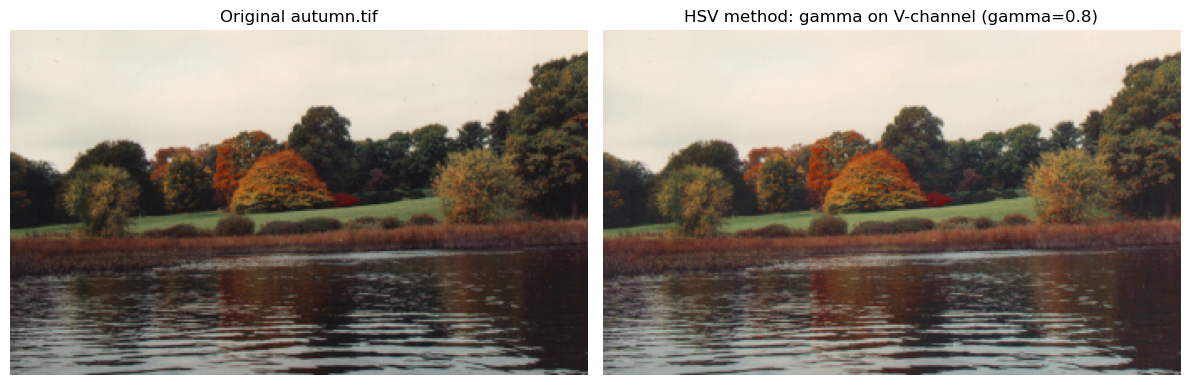

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(autumn_rgb)
plt.title('Original autumn.tif')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(autumn_hsv_gamma)
plt.title(f'HSV method: gamma on V-channel (gamma={gamma_hsv})')
plt.axis('off')

plt.tight_layout()
plt.show()

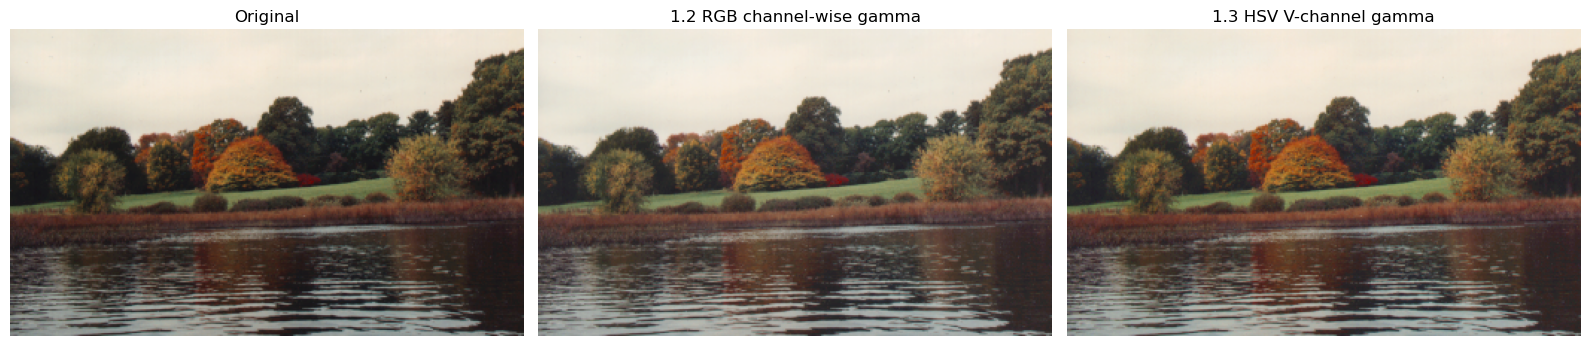

In [10]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(autumn_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(autumn_rgb_gamma)
plt.title('1.2 RGB channel-wise gamma')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(autumn_hsv_gamma)
plt.title('1.3 HSV V-channel gamma')
plt.axis('off')

plt.tight_layout()
plt.show()